# StockPortfolio.pro forensic growth audit

Reproducible, privacy-safe calculations for the 21 August 2026 audit. Inputs are reviewed aggregates; no credentials, customer identifiers, prompts, portfolio data or network calls are used.

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt

snapshot_date = '2026-08-21'
gross_gmv = 801.00
discounts = 88.58
partner_revenue = 183.97
orders = 9
refunds = 0
redeemed = 7
ask_buyers = 6
ask_calls = 76

assert round(gross_gmv - discounts, 2) == 712.42
assert round(1000 - gross_gmv, 2) == 199.00
assert round(1000 - partner_revenue, 2) == 816.03
assert redeemed / orders == 7 / 9
assert ask_buyers / redeemed == 6 / 7


## Revenue definitions

Gross GMV and founder revenue are deliberately separate. Direct Stripe retained revenue is zero because the sole GBP 7 payment was fully refunded.

In [2]:
revenue_summary = pd.DataFrame([
    {'metric': 'Gross AppSumo GMV', 'amount': gross_gmv, 'currency': 'USD'},
    {'metric': 'Marketplace discounts', 'amount': -discounts, 'currency': 'USD'},
    {'metric': 'Partner revenue', 'amount': partner_revenue, 'currency': 'USD'},
    {'metric': 'Gross gap to $1,000', 'amount': 1000 - gross_gmv, 'currency': 'USD'},
    {'metric': 'Founder-proceeds gap to $1,000', 'amount': 1000 - partner_revenue, 'currency': 'USD'},
])
revenue_summary

,metric,amount,currency
0,Gross AppSumo GMV,801.00,USD
1,Marketplace discounts,-88.58,USD
2,Partner revenue,183.97,USD
3,"Gross gap to $1,000",199.00,USD
4,"Founder-proceeds gap to $1,000",816.03,USD


## Customer-level payout reconciliation

In [3]:
customers = pd.DataFrame([
    ('CUSTOMER-01','Investor',79,16.35,13,3,'Active'),
    ('CUSTOMER-02','Pro',149,31.52,0,0,'Unredeemed'),
    ('CUSTOMER-03','Pro',149,36.24,2,3,'Active'),
    ('CUSTOMER-04','Investor',79,17.34,3,2,'Light'),
    ('CUSTOMER-05','Pro',149,35.95,54,5,'Active'),
    ('CUSTOMER-06','Starter',39,9.43,0,2,'Light'),
    ('CUSTOMER-07','Starter',39,8.87,2,3,'Active/light'),
    ('CUSTOMER-08','Starter',39,9.22,2,1,'Light'),
    ('CUSTOMER-09','Investor',79,19.05,0,0,'Unredeemed'),
], columns=['customer','tier','gross_usd','partner_revenue_usd','ask_calls','active_days','status'])
assert customers.gross_usd.sum() == gross_gmv
assert round(customers.partner_revenue_usd.sum(), 2) == partner_revenue
assert customers.ask_calls.sum() == ask_calls
customers

,customer,tier,gross_usd,partner_revenue_usd,ask_calls,active_days,status
0,CUSTOMER-01,Investor,79,16.35,13,3,Active
1,CUSTOMER-02,Pro,149,31.52,0,0,Unredeemed
2,CUSTOMER-03,Pro,149,36.24,2,3,Active
3,CUSTOMER-04,Investor,79,17.34,3,2,Light
4,CUSTOMER-05,Pro,149,35.95,54,5,Active
5,CUSTOMER-06,Starter,39,9.43,0,2,Light
6,CUSTOMER-07,Starter,39,8.87,2,3,Active/light
7,CUSTOMER-08,Starter,39,9.22,2,1,Light
8,CUSTOMER-09,Investor,79,19.05,0,0,Unredeemed


## Founder-proceeds scenarios

The new-to-AppSumo route is conditional on the portal's advertised 90% share, genuine new-customer eligibility and a conservative illustrative 10% discount. The first order must validate it.

In [4]:
gap = 1000 - partner_revenue
tier3_historical_payout = (31.52 + 36.24 + 35.95) / 3
blended_payout = partner_revenue / orders
new_customer_tier3_payout = 149 * 0.90 * 0.90
paths = pd.DataFrame([
    ('New AppSumo Pro via 90% link', math.ceil(gap / new_customer_tier3_payout), new_customer_tier3_payout, 'Conditional'),
    ('Existing AppSumo Pro', math.ceil(gap / tier3_historical_payout), tier3_historical_payout, 'Observed Tier 3 average'),
    ('Current blended AppSumo mix', math.ceil(gap / blended_payout), blended_payout, 'Observed blended average'),
    ('Direct Power annual', math.ceil(gap / 579), 579, 'Unvalidated direct'),
    ('Direct Desk annual', math.ceil(gap / 1961), 1961, 'Unvalidated professional'),
], columns=['path','buyers_required','proceeds_per_buyer','evidence'])
paths['modeled_total_proceeds'] = partner_revenue + paths.buyers_required * paths.proceeds_per_buyer
paths

,path,buyers_required,proceeds_per_buyer,evidence,modeled_total_proceeds
0,New AppSumo Pro via 90% link,7,120.690000,Conditional,1028.800000
1,Existing AppSumo Pro,24,34.570000,Observed Tier 3 average,1013.650000
2,Current blended AppSumo mix,40,20.441111,Observed blended average,1001.614444
3,Direct Power annual,2,579.000000,Unvalidated direct,1341.970000
4,Direct Desk annual,1,1961.000000,Unvalidated professional,2144.970000


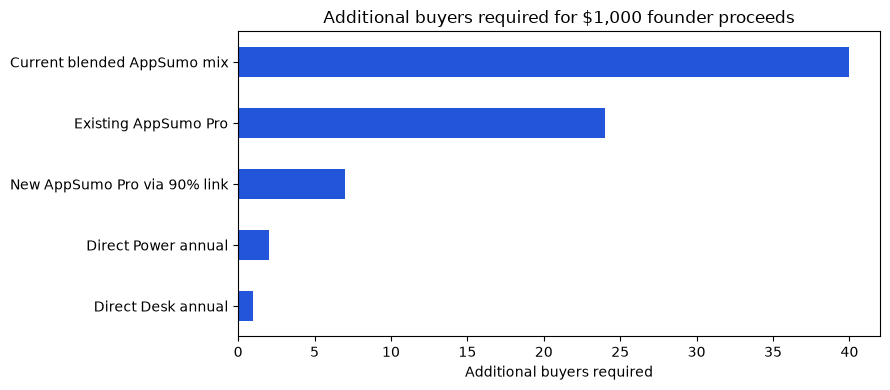

In [5]:
ax = paths.sort_values('buyers_required').plot.barh(
    x='path', y='buyers_required', legend=False, color='#2255d9', figsize=(9, 4)
)
ax.set_xlabel('Additional buyers required')
ax.set_ylabel('')
ax.set_title('Additional buyers required for $1,000 founder proceeds')
plt.tight_layout()
plt.show()

## Observed redeemed-buyer feature adoption

In [6]:
features = pd.DataFrame([
    ('Completed Ask',6,76,'Provider usage'),
    ('Summary/briefing',5,7,'Provider usage'),
    ('Stored alerts',4,45,'Stored documents; not proven opens'),
    ('Free-tool completion',1,15,'Canonical events; post-purchase'),
    ('Research share',1,1,'Canonical event'),
], columns=['feature','buyers','uses','coverage'])
features['buyer_share'] = features.buyers / redeemed
features

,feature,buyers,uses,coverage,buyer_share
0,Completed Ask,6,76,Provider usage,0.857143
1,Summary/briefing,5,7,Provider usage,0.714286
2,Stored alerts,4,45,Stored documents; not proven opens,0.571429
3,Free-tool completion,1,15,Canonical events; post-purchase,0.142857
4,Research share,1,1,Canonical event,0.142857


## Validation notes

- AppSumo/Stripe are finance truth; redemption and funnel events are not orders.
- Missing acquisition/page identity is unknown, not Direct or zero.
- Ask is the strongest observed post-purchase activation behavior, not a proven purchase cause.
- The paying sample is nine orders and seven redeemed users.
- Current GA4 API access is blocked because the Analytics Data API is disabled for the configured GCP project.